In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster


In [2]:
# Load CSV file
cancer_burden_ml_df = pd.read_csv("../data/master_cancer_summary.csv")
cancer_burden_ml_df

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248
3,Colon and Rectum,Moderate,43.11,15.47,0.67,0.36,66524,6246,110144
4,Non-Hodgkin Lymphoma,Moderate,16.39,5.07,0.73,0.31,75164,12805,144707
5,Urinary Bladder,Moderate,14.81,3.43,0.80,0.23,26443,6350,95985
6,Prostate,Low,127.66,23.34,0.99,0.18,28109,2603,74227
7,Female Breast,Low,110.44,19.30,0.92,0.17,34980,3540,76101
8,Melanomas of the Skin,Low,8.53,1.24,0.95,0.15,8537,2707,78912


In [3]:
cluster_features = cancer_burden_ml_df[
    [
        "incidence",
        "mortality",
        "survival",
        "mortality_ratio",
        "initial_care",
        "continuing_care",
        "last_year_of_life"
    ]
]

cluster_features

,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life
0,12.06,9.97,0.09,0.83,108166,18427,125031
1,11.06,8.33,0.19,0.75,62776,18219,92134
2,53.77,37.13,0.21,0.69,68293,12389,110248
3,43.11,15.47,0.67,0.36,66524,6246,110144
4,16.39,5.07,0.73,0.31,75164,12805,144707
5,14.81,3.43,0.80,0.23,26443,6350,95985
6,127.66,23.34,0.99,0.18,28109,2603,74227
7,110.44,19.30,0.92,0.17,34980,3540,76101
8,8.53,1.24,0.95,0.15,8537,2707,78912


In [4]:
# Create scaler

scaler = StandardScaler()

In [5]:
# Scale features

cluster_features_scaled = scaler.fit_transform(
    cluster_features
)

In [6]:
cluster_features_scaled

array([[-0.75100612, -0.34441434, -1.56704704,  1.64439003,  1.8817661 ,
         1.52840161,  1.07212132],
       [-0.77437041, -0.49593612, -1.26950647,  1.33282139,  0.3272319 ,
         1.49374473, -0.38536605],
       [ 0.22351836,  2.16493413, -1.20999835,  1.09914492,  0.51618024,
         0.52235245,  0.41716689],
       [-0.02554496,  0.16373797,  0.15868831, -0.18607571,  0.45559485,
        -0.50119176,  0.41255921],
       [-0.64983875, -0.79713185,  0.33721265, -0.38080611,  0.7515009 ,
         0.59166621,  1.94385799],
       [-0.68675433, -0.94865363,  0.54549106, -0.69237475, -0.91711467,
        -0.48386332, -0.21474916],
       [ 1.94990565,  0.89085772,  1.11081816, -0.88710515, -0.86005686,
        -1.10818697, -1.17872795],
       [ 1.5475726 ,  0.51759675,  0.90253975, -0.92605123, -0.62473621,
        -0.9520644 , -1.09570119],
       [-0.83348206, -1.15099064,  0.99180193, -1.00394339, -1.53036625,
        -1.09085853, -0.97116105]])

In [7]:
# Create linkage matrix

linkage_matrix = linkage(
    cluster_features_scaled,
    method="ward"
)

linkage_matrix

array([[ 6.        ,  7.        ,  0.6578266 ,  2.        ],
       [ 5.        ,  8.        ,  1.29437913,  2.        ],
       [ 0.        ,  1.        ,  2.17971495,  2.        ],
       [ 3.        ,  4.        ,  2.23820895,  2.        ],
       [ 2.        , 11.        ,  3.49849225,  3.        ],
       [10.        , 12.        ,  4.11707924,  4.        ],
       [ 9.        , 14.        ,  5.22417353,  6.        ],
       [13.        , 15.        ,  7.59271571,  9.        ]])

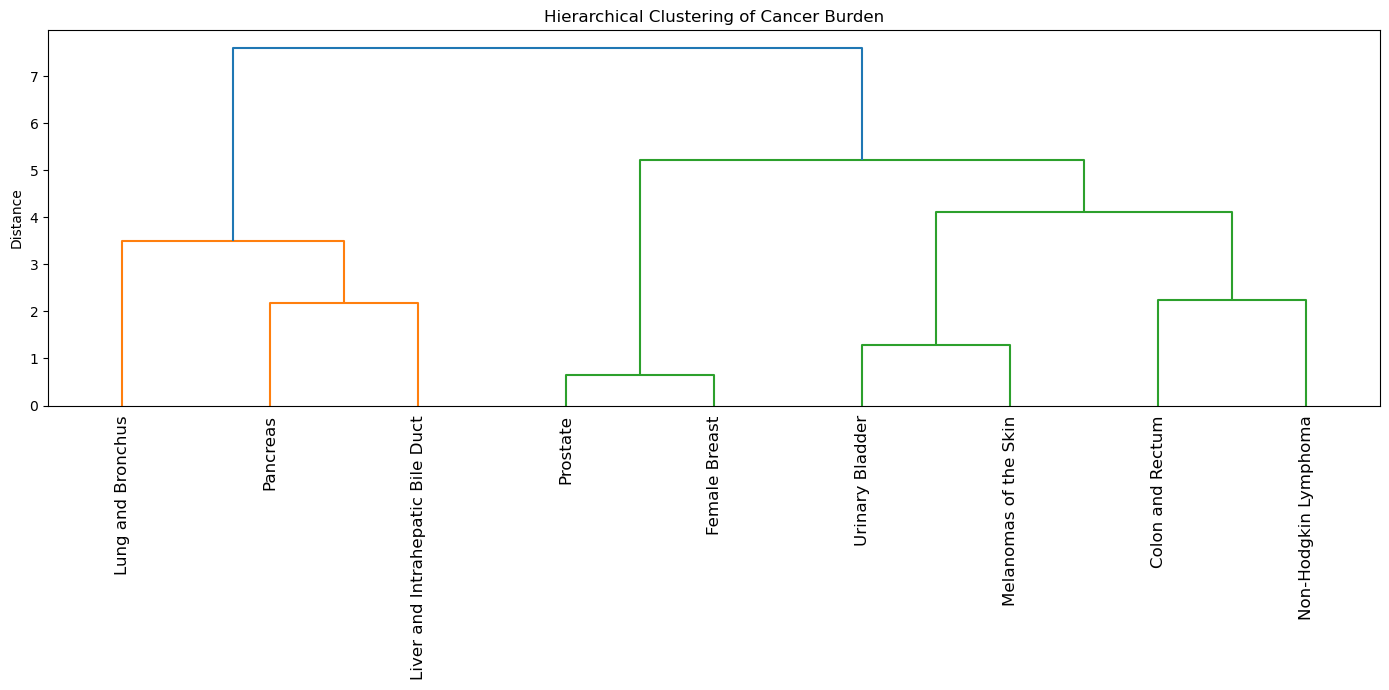

In [18]:
plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    labels=cancer_burden_ml_df["cancer_type"].values,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Cancer Burden")
plt.ylabel("Distance")

plt.tight_layout()

plt.savefig(
    "../Shinny_app/Cancer_Burden_Dashboard/www/dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
import os

os.makedirs(
    "../Shinny_app/Cancer_Burden_Dashboard/www",
    exist_ok=True
)

In [19]:
os.listdir("../Shinny_app/Cancer_Burden_Dashboard/www")

['dendrogram.png']

## Interpretation:

### Group 1: Prostate and Female Breast

Prostate and Female Breast cancers share similar burden characteristics, including high incidence, high survival rates, low mortality ratios, and relatively lower overall disease burden compared to other cancer types.

### Group 2: Pancreas, Liver and Intrahepatic Bile Duct

Pancreatic and liver cancers were grouped together because both exhibit high mortality ratios, low survival rates, and substantial healthcare burden, indicating particularly poor clinical outcomes.

### Group 3: Colon and Rectum, Non-Hodgkin Lymphoma

Colon cancer and Non-Hodgkin Lymphoma formed an intermediate cluster characterized by moderate survival outcomes and moderate mortality burden.

In [9]:
# Create 3 clusters from the dendrogram

cluster_labels = fcluster(
    linkage_matrix,
    t=3,
    criterion="maxclust"
)

cluster_labels

array([1, 1, 1, 3, 3, 3, 2, 2, 3], dtype=int32)

In [10]:
# Add cluster assignments to dataframe

cancer_burden_ml_df["cluster"] = cluster_labels

In [11]:
# Compare Machine Learning Clusters with Diagnosis Challenge Categories
# View cancer types and assigned clusters

cancer_burden_ml_df[
    [
        "cancer_type",
        "diagnosis_challenge",
        "cluster"
    ]
]

,cancer_type,diagnosis_challenge,cluster
0,Pancreas,High,1
1,Liver and Intrahepatic Bile Duct,High,1
2,Lung and Bronchus,Moderate-High,1
3,Colon and Rectum,Moderate,3
4,Non-Hodgkin Lymphoma,Moderate,3
5,Urinary Bladder,Moderate,3
6,Prostate,Low,2
7,Female Breast,Low,2
8,Melanomas of the Skin,Low,3
